# **Preprocessing - Fraud Detection Model**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
import plotly.express as px

Required libraries are imported for data processing, visualization, machine learning models, and evaluation.

In [ ]:
file_path = "/content/creditcard.csv"
df = pd.read_csv(file_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


The dataset is loaded into a Pandas DataFrame and basic details, including missing values, are checked.

In [ ]:
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3973 entries, 0 to 3972
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    3973 non-null   int64  
 1   V1      3973 non-null   float64
 2   V2      3973 non-null   float64
 3   V3      3973 non-null   float64
 4   V4      3973 non-null   float64
 5   V5      3973 non-null   float64
 6   V6      3973 non-null   float64
 7   V7      3973 non-null   float64
 8   V8      3973 non-null   float64
 9   V9      3973 non-null   float64
 10  V10     3973 non-null   float64
 11  V11     3973 non-null   float64
 12  V12     3973 non-null   float64
 13  V13     3973 non-null   float64
 14  V14     3973 non-null   float64
 15  V15     3973 non-null   float64
 16  V16     3973 non-null   float64
 17  V17     3973 non-null   float64
 18  V18     3973 non-null   float64
 19  V19     3973 non-null   float64
 20  V20     3973 non-null   float64
 21  V21     3973 non-null  

Dataset information and first few rows of data for quick overview and structure understanding.

In [ ]:
print("\nMissing values in dataset:")
print(df.isnull().sum())


Missing values in dataset:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


Listing the missing values in the dataset for easy analysis.

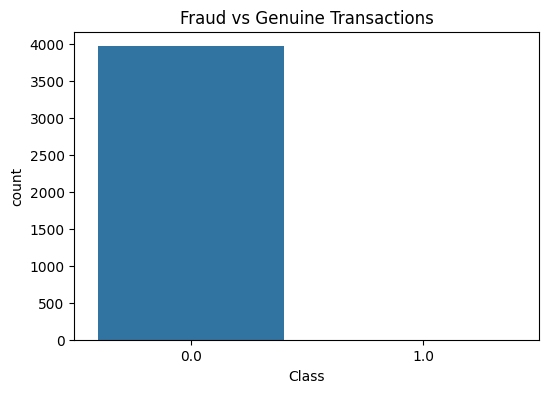

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Class"])
plt.title("Fraud vs Genuine Transactions")
plt.show()

A count plot is used to see how imbalanced the dataset is (genuine vs. fraudulent transactions).

# **Data Preprocessing**

In [ ]:
from imblearn.over_sampling import SMOTE
print("Missing values in dataset:\n", df.isnull().sum())
df = df.dropna()
X = df.drop(["Class"], axis=1)
y = df["Class"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
smote = SMOTE(sampling_strategy=0.5, k_neighbors=1, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
print("Preprocessing completed successfully!")

Missing values in dataset:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Preprocessing completed successfully!


The dataset is trained and dataset is highly imbalanced, so Synthetic Minority Over-sampling Technique (SMOTE) is applied also splitting of data is done.

# **Trained Model Prediction**

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))


Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       805
         1.0       1.00      1.00      1.00       386

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191


XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       805
         1.0       0.99      1.00      1.00       386

    accuracy                           1.00      1191
   macro avg       1.00      1.00      1.00      1191
weighted avg       1.00      1.00      1.00      1191



Both models predict on the test data and gives Classification reports for both models are displayed, showing precision, recall, and F1-score.

**Confusion Matrix Visualization**

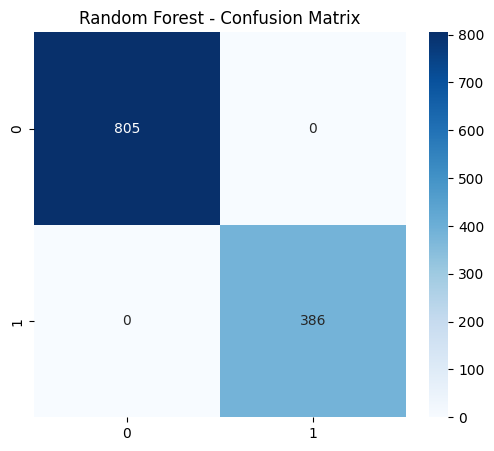

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.show()

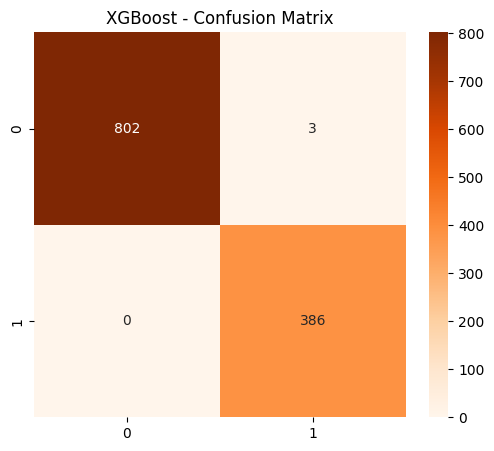

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost - Confusion Matrix")
plt.show()

Both the heatmaps are used to visualize the confusion matrices for better interpretation.

**Precision-Recall Curve**

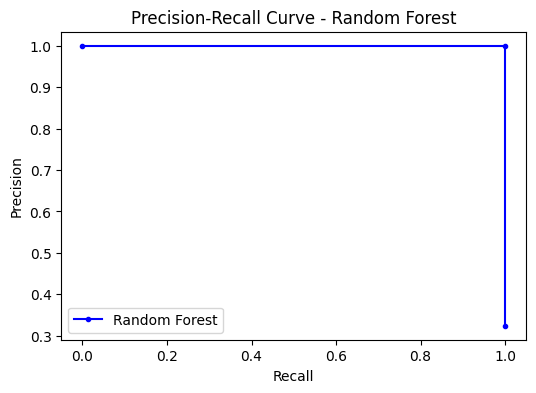

In [ ]:
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
plt.plot(recall_rf, precision_rf, marker='.', label="Random Forest", color="blue")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend()
plt.show()

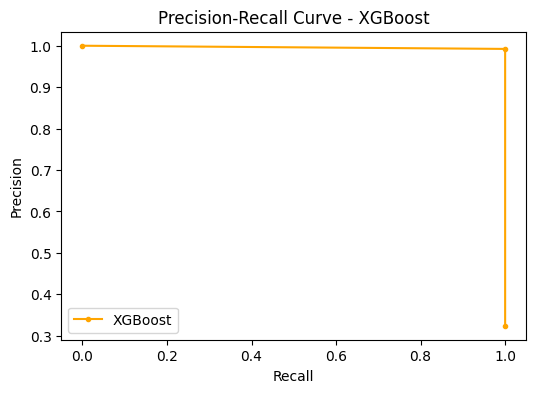

In [ ]:
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
plt.plot(recall_xgb, precision_xgb, marker='.', label="XGBoost", color="orange")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend()
plt.show()

These graphs are plotted to analyze precision and recall trade-offs.

**ROC Curve and AUC Score**

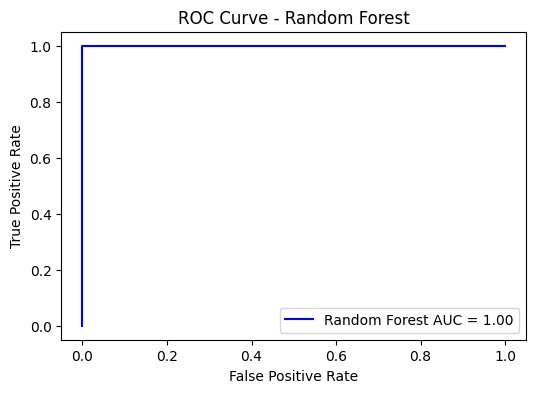

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_rf:.2f}", color="blue")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

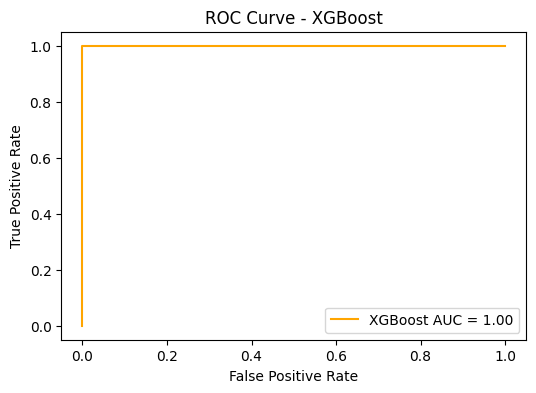

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {roc_auc_xgb:.2f}", color="orange")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

The ROC curve and AUC (Area Under Curve) are plotted to evaluate classification performance.

**Feature Importance (Interactive Visualization)**

In [ ]:
feature_importance_rf = pd.DataFrame({'Feature': df.columns[:-1], 'Importance': rf_model.feature_importances_})
feature_importance_rf = feature_importance_rf.sort_values(by="Importance", ascending=False)

fig_rf = px.bar(feature_importance_rf, x="Importance", y="Feature", title="Feature Importance (Random Forest)", orientation="h", color_discrete_sequence=["blue"])
fig_rf.show()

In [ ]:
feature_importance_xgb = pd.DataFrame({'Feature': df.columns[:-1], 'Importance': xgb_model.feature_importances_})
feature_importance_xgb = feature_importance_xgb.sort_values(by="Importance", ascending=False)

fig_xgb = px.bar(feature_importance_xgb, x="Importance", y="Feature", title="Feature Importance (XGBoost)", orientation="h", color_discrete_sequence=["orange"])
fig_xgb.show()

Both the bar charts uses Plotly shows which features contribute most to predictions.